# ChemKAN PyTorch Reproduction — Results & Status

**Date:** 2026-08-17 &nbsp;•&nbsp; **Project:** Interdisciplinary Project, TU Wien

**Objective.** Reproduce, in PyTorch, the ChemKAN approach of Koenig, Kim & Deng (2025) —
a Kolmogorov–Arnold Network trained as a *neural ODE* for chemical kinetics — and evaluate
it on the paper's **biodiesel** and **hydrogen** benchmarks against ground-truth
trajectories.

> **Independent reconstruction.** The paper's authors did **not** release ChemKAN source
> code. Everything here is an independent PyTorch reconstruction built from the publication;
> where the paper leaves a detail unspecified, our choice is flagged as an assumption
> (see §3 and `src/chemkan/ASSUMPTIONS.md`).

This notebook is a **presentation / evaluation artifact** — it reuses the repository's own
loaders, model constructors, dynamics, checkpoint/normalizer reconstruction, and evaluation
code. It does not redesign the architecture or launch long training runs.

### Setup

Run this notebook from within the repository (any working directory inside it). The cell
below locates the `chemkan` package, puts `scripts/` on the path (for the experiment
helpers `_data` / `_chemistry`), and resolves checkpoint locations robustly. Two safety
switches at the top keep expensive work off by default.

In [1]:
%matplotlib inline
import os, sys, json, warnings
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")            # keep torch/JIT import warnings out of the way
torch.manual_seed(0)

# --- safety switches (keep both False for a meeting run) ---
RUN_EXPENSIVE  = False     # never launch full/long training automatically
RUN_SMOKE_TEST = False     # allow a clearly-labeled *tiny* training run only when True

# --- locate the package + scripts regardless of the launch directory ---
def _find_chemkan_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "src" / "chemkan" / "__init__.py").exists():
            return base
    raise RuntimeError("Could not locate the chemkan package directory.")

CHEMKAN_DIR = _find_chemkan_dir()
REPO_ROOT   = CHEMKAN_DIR.parent
for p in (CHEMKAN_DIR / "src", CHEMKAN_DIR / "scripts"):   # src is redundant if pip -e installed
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
DEVICE = torch.device("cpu")

# checkpoints are written to wherever training was launched -> search a few sensible spots
def resolve_ckpt(name):
    for c in (CHEMKAN_DIR / name, REPO_ROOT / name, Path.cwd() / name):
        if c.exists():
            return c
    return None

BIODIESEL_CKPT = resolve_ckpt("biodiesel_kinetic.pt")
HYDROGEN_CKPT  = resolve_ckpt("hydrogen_chemkan.pt")

print("chemkan dir          :", CHEMKAN_DIR)
print("repo root            :", REPO_ROOT)
print("biodiesel checkpoint :", BIODIESEL_CKPT)
print("hydrogen  checkpoint :", HYDROGEN_CKPT)
print("RUN_EXPENSIVE =", RUN_EXPENSIVE, " RUN_SMOKE_TEST =", RUN_SMOKE_TEST)

chemkan dir          : /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/chemkan
repo root            : /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien
biodiesel checkpoint : /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/biodiesel_kinetic.pt
hydrogen  checkpoint : /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/hydrogen_chemkan.pt
RUN_EXPENSIVE = False  RUN_SMOKE_TEST = False


## 1 · Current status at a glance

Populated **from the repository** (import checks + file/artifact checks), not hand-written.


In [2]:
import importlib

def _implemented(modpath, attr):
    try:
        return hasattr(importlib.import_module(modpath), attr)
    except Exception:
        return False

def _tested(testfile):
    return (CHEMKAN_DIR / "tests" / testfile).exists()

def mk(flag):      # bool -> label
    return "✅ yes" if flag else "❌ no"

rows = [
    ("AddKAN layer",              _implemented("chemkan.kan.layers", "AddKANLayer"),  _tested("test_layers.py")),
    ("LeanKAN layer",             _implemented("chemkan.kan.layers", "LeanKANLayer"), _tested("test_layers.py")),
    ("RBF edge functions",        _implemented("chemkan.kan.rbf", "RBFEdgeFunctions"),_tested("test_rbf.py")),
    ("Kinetic core",              _implemented("chemkan.model", "KineticCore"),       _tested("test_model.py")),
    ("Thermodynamic superstruct", _implemented("chemkan.model", "ThermodynamicSuperstructure"), _tested("test_model.py")),
    ("Full ChemKAN",              _implemented("chemkan.model", "ChemKAN"),           _tested("test_model.py")),
    ("Stage 1 (train_kinetic_stage)", _implemented("chemkan.training","train_kinetic_stage"), _tested("test_refactor.py")),
    ("Stage 2 (train_full_chemkan)",  _implemented("chemkan.training","train_full_chemkan"),  _tested("test_refactor.py")),
    ("Eq. 18 MSE (trajectory_mse)",   _implemented("chemkan.losses","trajectory_mse"),        _tested("test_losses.py")),
    ("Element-conservation (PINN)",   _implemented("chemkan.losses","element_conservation_loss"), _tested("test_losses.py")),
]

lines = ["| Component | Implemented | Test present |", "|---|---|---|"]
for name, impl, test in rows:
    lines.append(f"| {name} | {mk(impl)} | {mk(test)} |")

# solver / FSA / artifacts
solver_used = "Tsit5 (`torchdiffeq.odeint`, pinned GitHub commit) — scripts default `method=\"tsit5\"`"
extra = [
    "",
    "| Item | Status |",
    "|---|---|",
    f"| Solver currently used | {solver_used} |",
    "| Sensitivity method | direct autograd through `odeint` |",
    "| Forward Sensitivity Analysis (FSA) | ❌ **NOT YET** (largest remaining method gap, see §9) |",
    f"| Biodiesel checkpoint | {'✅ ' + str(BIODIESEL_CKPT) if BIODIESEL_CKPT else '❌ not found'} |",
    f"| Hydrogen checkpoint  | {'✅ ' + str(HYDROGEN_CKPT) if HYDROGEN_CKPT else '❌ not found (Stage-2 pending)'} |",
]
display(Markdown("\n".join(lines + extra)))

| Component | Implemented | Test present |
|---|---|---|
| AddKAN layer | ✅ yes | ✅ yes |
| LeanKAN layer | ✅ yes | ✅ yes |
| RBF edge functions | ✅ yes | ✅ yes |
| Kinetic core | ✅ yes | ✅ yes |
| Thermodynamic superstruct | ✅ yes | ✅ yes |
| Full ChemKAN | ✅ yes | ✅ yes |
| Stage 1 (train_kinetic_stage) | ✅ yes | ✅ yes |
| Stage 2 (train_full_chemkan) | ✅ yes | ✅ yes |
| Eq. 18 MSE (trajectory_mse) | ✅ yes | ✅ yes |
| Element-conservation (PINN) | ✅ yes | ✅ yes |

| Item | Status |
|---|---|
| Solver currently used | Tsit5 (`torchdiffeq.odeint`, pinned GitHub commit) — scripts default `method="tsit5"` |
| Sensitivity method | direct autograd through `odeint` |
| Forward Sensitivity Analysis (FSA) | ❌ **NOT YET** (largest remaining method gap, see §9) |
| Biodiesel checkpoint | ✅ /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/biodiesel_kinetic.pt |
| Hydrogen checkpoint  | ✅ /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/hydrogen_chemkan.pt |

## 2 · Paper architecture in chemistry terms

The model learns the **right-hand side of a chemical-kinetic ODE** (paper p. 3, Eqs. 1–3):

$$\frac{d\mathbf{u}}{dt} = f(\mathbf{u}, t), \qquad \mathbf{u} = [\,Y_1,\dots,Y_m,\;T\,]$$

where $Y_k$ are species mass fractions and $T$ is temperature. ChemKAN splits $f$ into a
**kinetic core** and a **thermodynamic superstructure** (paper pp. 6–7, Eqs. 13–17, Fig. 2):

$$\frac{d\mathbf{Y}}{dt} = \mathrm{KAN_{kin}}([\mathbf{Y},T]), \qquad
  \frac{dT}{dt} = \underbrace{\mathrm{Linear}\!\left(\tfrac{d\mathbf{Y}}{dt}\right)}_{\approx\,-\sum_k h_k \dot Y_k / c_p}
  + \mathrm{KAN_{cor}}([\mathbf{Y},T])$$

In chemistry terms: the **kinetic core** predicts how fast every species is being produced
or consumed at the current composition and temperature (it replaces the stiff Arrhenius
reaction-rate machinery with a learned function). The **temperature equation** is mostly the
enthalpy balance — a linear combination of the species rates weighted by formation enthalpies
over heat capacity — plus a small learned correction. Integrating this ODE in time
reconstructs the full reacting trajectory, exactly as a stiff solver would for the true
mechanism, but far cheaper to evaluate. (Full KAN/RBF details are in §8 and the paper,
Eqs. 11–12; omitted here.)

## 3 · Reproduction choices / open differences

What the paper specifies vs. what this reconstruction does. Full log in
`src/chemkan/ASSUMPTIONS.md`.

| Item | Paper-defined | Current implementation | Status / reason |
|---|---|---|---|
| Kinetic core ordering | AddKAN → LeanKAN (Eq. 13) | AddKAN → LeanKAN | ✅ matches |
| Layer-input `tanh` | `tanh` normalization at each KAN layer input | same, inside `RBFEdgeFunctions` | ✅ matches |
| Eq. 18 loss normalization | `[0,1]` min-max, train-only stats | `MinMaxNormalizer`, train-only | ✅ matches |
| Stage-1 temperature `T(t)` | observed temperature supplied | `ObservedTemperature`, **interpolated** at adaptive solver times | ✅ behavior matches; interpolation scheme is our choice |
| ODE state representation | physical `[Y,T]` | physical `[Y,T]` (derivatives physical) | ✅ matches |
| **Pre-KAN input scaling** | *not specified* | global train-set min-max of `[Y,T]` **before** the KAN | ⚠️ **reproduction ASSUMPTION** (avoids `tanh` saturation on dimensional T; ODE state stays physical) |
| Base activation (Eq. 11 Swish path) | present in Eq. 11 | **OFF** by default (`use_base_act=False`) | ✅ matches reported parameter counts (156 / 344); ON is a sensitivity variant |
| Integrator | Tsit5 | **Tsit5** via pinned GitHub `torchdiffeq` | ✅ same method |
| Sensitivity / gradients | Forward Sensitivity Analysis (FSA) | direct autograd through `odeint` | ❌ **FSA not implemented** — see §9 |

The **pre-KAN input scaling** is the one substantive design assumption: the paper does not
state the representation fed to the first KAN layer, and raw combustion temperatures saturate
the internal `tanh`. We min-max scale the model input only; the integrated state and the
predicted derivatives remain physical.

## 4 · Dataset sanity — biodiesel

Isothermal transesterification: 6 species, each trajectory at its own constant temperature.
Loaded with the repository's own loader (`_data.load_biodiesel`).

In [3]:
from _data import load_biodiesel

bd_train = load_biodiesel("train")
bd_test  = load_biodiesel("test")
bd_species = bd_train["species"]
m_bd = bd_train["species_TBm"].shape[-1]

t_bd   = bd_train["t"].numpy()
Ytr    = bd_train["species_TBm"].numpy()      # (T, B, m) physical mass fractions
Yte    = bd_test["species_TBm"].numpy()
Ttr    = bd_train["T_const"].numpy()
Tte    = bd_test["T_const"].numpy()

print("species order      :", bd_species)
print("train states (T,B,m):", Ytr.shape, "  test:", Yte.shape)
print(f"time               : {t_bd[0]:.3g} .. {t_bd[-1]:.3g}  ({len(t_bd)} points)")
print(f"train temperature  : {Ttr.min():.1f} .. {Ttr.max():.1f} K   (isothermal per trajectory)")
print(f"test  temperature  : {Tte.min():.1f} .. {Tte.max():.1f} K")
print("initial-condition ranges (mass fraction) per species:")
for k, sp in enumerate(bd_species):
    y0 = Ytr[0, :, k]
    print(f"   {sp:6s}  Y0 in [{y0.min():.3f}, {y0.max():.3f}]")

species order      : ['TG', 'ROH', 'DG', 'MG', 'GL', 'RCO2R']
train states (T,B,m): (30, 20, 6)   test: (30, 10, 6)
time               : 0 .. 30  (30 points)
train temperature  : 324.0 .. 340.8 K   (isothermal per trajectory)
test  temperature  : 325.3 .. 341.6 K
initial-condition ranges (mass fraction) per species:
   TG      Y0 in [0.504, 1.903]
   ROH     Y0 in [0.542, 1.996]
   DG      Y0 in [0.000, 0.000]
   MG      Y0 in [0.000, 0.000]
   GL      Y0 in [0.000, 0.000]
   RCO2R   Y0 in [0.000, 0.000]


**Paper setup (p. 10 / Fig. 3):** 20 training + 10 test trajectories, 30 s window,
30 time points, isothermal; ChemKAN kinetic core with hidden width 4, RBF grid 3, `n_mu=2`
(156 parameters, base path off). Verify the printed shapes/counts above match.

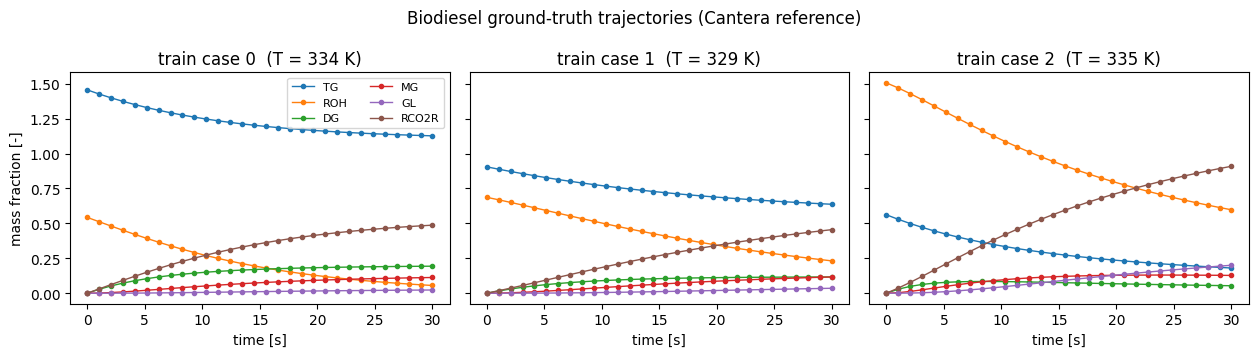

In [4]:
# ground-truth trajectories for the first few training cases (markers = observed samples)
ncase = 3
fig, axes = plt.subplots(1, ncase, figsize=(4.2 * ncase, 3.6), sharey=True)
for j in range(ncase):
    ax = axes[j]
    for k, sp in enumerate(bd_species):
        ax.plot(t_bd, Ytr[:, j, k], marker="o", ms=3, lw=1, label=sp)
    ax.set_title(f"train case {j}  (T = {Ttr[j]:.0f} K)")
    ax.set_xlabel("time [s]")
axes[0].set_ylabel("mass fraction [-]")
axes[0].legend(fontsize=8, ncol=2)
fig.suptitle("Biodiesel ground-truth trajectories (Cantera reference)")
fig.tight_layout(); plt.show()

## 5 · Biodiesel ChemKAN result

Mirrors `scripts/evaluate_biodiesel.py`: rebuild the kinetic core from the checkpoint's
stored architecture, **reconstruct the pre-KAN input scaling from checkpoint metadata**
(never refit), integrate the held-out **test** split, and compare against ground truth.

In [5]:
from _data import load_input_scaling
from chemkan.model import KineticCore
from chemkan.dynamics import KineticDynamics
from chemkan.temperature import ConstantTemperature
from chemkan.normalization import MinMaxNormalizer
from chemkan.solver import SolverConfig, integrate
from chemkan.losses import trajectory_mse

def _solver_from_ckpt(ckpt):
    s = ckpt["solver"]
    return SolverConfig(method=s["method"], rtol=s["rtol"], atol=s["atol"],
                        sensitivity=s["sensitivity"])

if BIODIESEL_CKPT is None:
    display(Markdown(
        "### ⚠️ NOT AVAILABLE YET — no biodiesel checkpoint found\n"
        "Generate one (from the `chemkan/` directory):\n\n"
        "```bash\n"
        "python scripts/train_biodiesel.py --epochs 10000   # paper reproduction\n"
        "python scripts/train_biodiesel.py --epochs 100     # quick smoke run\n"
        "```\n"
        "then re-run this notebook."))
    bd_eval = None
else:
    ckpt = torch.load(BIODIESEL_CKPT, map_location=DEVICE, weights_only=False)
    arch = ckpt["architecture"]
    if list(ckpt.get("data", {}).get("species", bd_species)) != list(bd_species):
        raise ValueError("checkpoint species order differs from the dataset")

    core = KineticCore(species_dim=m_bd, hidden_dim=arch["hidden_dim"],
                       num_basis=arch["num_basis"], n_mu=arch["n_mu"],
                       use_base_act=arch["use_base_act"]).to(DEVICE)
    core.load_state_dict(ckpt["model_state"]); core.eval()
    n_params = sum(p.numel() for p in core.parameters())

    input_norm = load_input_scaling(ckpt, DEVICE)                 # full-state [Y,T] scaling
    solver = _solver_from_ckpt(ckpt)
    dyn = KineticDynamics(core, ConstantTemperature(bd_test["T_const"]),
                          input_normalizer=input_norm).to(DEVICE)
    loss_norm = MinMaxNormalizer(bd_test["u_min"], bd_test["u_max"]).to(DEVICE)  # species-only

    Y0 = bd_test["Y0"].to(DEVICE); tt = bd_test["t"].to(DEVICE)
    with torch.no_grad():
        pred = integrate(dyn, Y0, tt, solver)                     # (T, B, m) physical
        mse = trajectory_mse(loss_norm.normalize(pred),
                             loss_norm.normalize(bd_test["species_TBm"].to(DEVICE))).item()
    bd_eval = dict(ckpt=ckpt, pred=pred.cpu().numpy(), mse=mse, n_params=n_params, arch=arch)
    print(f"checkpoint      : {BIODIESEL_CKPT.name}")
    print(f"architecture    : {arch}")
    print(f"parameters      : {n_params}")
    print(f"solver          : {ckpt['solver']}")
    print(f"training        : {ckpt.get('training')}")
    print(f"input scaling   : {ckpt['input_scaling']['method']}")
    print(f"TEST normalized trajectory MSE (Eq. 18): {mse:.3e}")

checkpoint      : biodiesel_kinetic.pt
architecture    : {'hidden_dim': 4, 'num_basis': 3, 'n_mu': 2, 'use_base_act': False}
parameters      : 156
solver          : {'method': 'tsit5', 'rtol': 1e-06, 'atol': 1e-08, 'sensitivity': 'direct_autograd'}
training        : {'learning_rate': 0.002, 'epochs': 10000, 'seed': 0, 'alpha_pinn': None, 'use_pinn': False}
input scaling   : minmax
TEST normalized trajectory MSE (Eq. 18): 8.140e-02


> **Note on training budget.** The paper trains for ~10⁴ epochs. Read the printed
> `training.epochs` above — if it is small, this checkpoint is a *smoke run* and the metrics
> below reflect an **undertrained** model (useful to validate the pipeline, not the final
> accuracy).

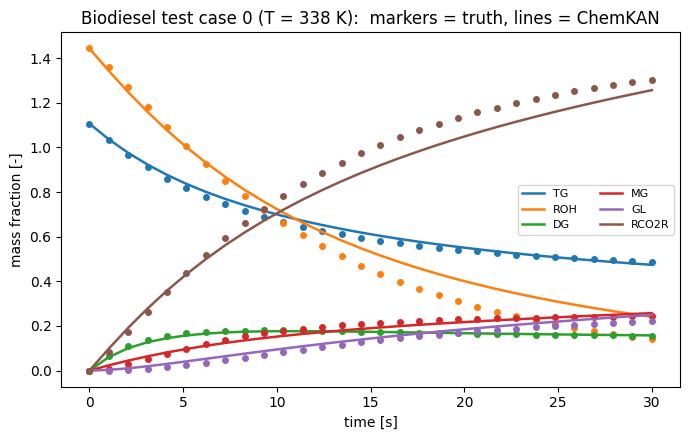

| species | RMSE [mass frac] | MAE [mass frac] |
|---|---|---|
| TG | 4.164e-02 | 2.701e-02 |
| ROH | 7.405e-02 | 5.810e-02 |
| DG | 1.715e-02 | 1.023e-02 |
| MG | 2.589e-02 | 1.735e-02 |
| GL | 2.297e-02 | 1.965e-02 |
| RCO2R | 5.815e-02 | 4.321e-02 |

In [6]:
if bd_eval is not None:
    ep = (bd_eval["ckpt"].get("training") or {}).get("epochs")
    if ep is not None and ep < 1000:
        display(Markdown(f"### ⚠️ Smoke checkpoint: trained for only **{ep} epochs** "
                         f"(paper ≈ 10⁴). Treat the curves/metrics below as a pipeline "
                         f"check, not final accuracy."))

    # --- pick one unseen test trajectory: ground truth (markers) vs ChemKAN (lines) ---
    j = 0
    pred = bd_eval["pred"]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for k, sp in enumerate(bd_species):
        ax.plot(t_bd, Yte[:, j, k], marker="o", ls="none", ms=4, color=f"C{k}")
        ax.plot(t_bd, pred[:, j, k], "-", lw=1.8, color=f"C{k}", label=sp)
    ax.set_xlabel("time [s]"); ax.set_ylabel("mass fraction [-]")
    ax.set_title(f"Biodiesel test case {j} (T = {Tte[j]:.0f} K):  markers = truth, lines = ChemKAN")
    ax.legend(fontsize=8, ncol=2); fig.tight_layout(); plt.show()

    # --- per-species physical error over ALL test trajectories ---
    diff = pred - Yte                                    # (T, B, m)
    rmse = np.sqrt((diff ** 2).mean(axis=(0, 1)))        # per species
    mae  = np.abs(diff).mean(axis=(0, 1))
    lines = ["| species | RMSE [mass frac] | MAE [mass frac] |", "|---|---|---|"]
    for k, sp in enumerate(bd_species):
        lines.append(f"| {sp} | {rmse[k]:.3e} | {mae[k]:.3e} |")
    display(Markdown("\n".join(lines)))

## 6 · Dataset / chemistry sanity — hydrogen

Non-isothermal H₂/O₂ ignition (h2o2 mechanism). 9 species; the full ODE state is
`[Y_1..Y_9, T]`. Species order is validated against the element table used by the PINN
term.

In [7]:
from _data import load_hydrogen
from _chemistry import SPECIES as H2_SPECIES, ELEMENTS, assert_species_order
import _data

hy_train = load_hydrogen("train")
hy_species = hy_train["species"]
assert_species_order(hy_species)                         # raises if order != element table
print("species order OK   :", hy_species)

t_hy = hy_train["t"].numpy()
full = hy_train["full_TBm1"].numpy()                     # (T, B, m+1) physical [Y, T]
m_hy = hy_train["species_TBm"].shape[-1]
print("elements           :", list(ELEMENTS))
print("train full state (T,B,m+1):", full.shape, "  (m =", m_hy, "species + temperature)")
print(f"time window        : {t_hy[0]:.3g} .. {t_hy[-1]:.3g} s  ({len(t_hy)} points, "
      f"dt~{np.mean(np.diff(t_hy)):.2e} s)")

# --- condition grid + held-out test condition from raw metadata ---
npz = np.load(_data.DATA_DIR / "hydrogen.npz", allow_pickle=True)
ics, is_test = npz["ics"], npz["is_test"].astype(bool)   # ics: (N, 2) = [T0, phi]
print(f"\ncondition grid     : {ics.shape[0]} conditions, {int(is_test.sum())} held-out (test)")
print("held-out test condition(s) [T0 (K), phi]:")
for row in ics[is_test]:
    print("   ", np.round(row, 4))
target = np.array([1150.0, 1.3])
is_paper = np.any(np.all(np.isclose(ics[is_test], target, atol=[1.0, 0.05]), axis=1))
print(f"\nMatches paper held-out [T0=1150 K, phi=1.3]? -> {bool(is_paper)}")
print("(If False, the current generated grid's held-out condition simply differs from the "
      "paper's; not claimed to match.)")

species order OK   : ['H2', 'H', 'O', 'O2', 'OH', 'H2O', 'HO2', 'H2O2', 'N2']
elements           : ['H', 'O', 'N']
train full state (T,B,m+1): (50, 35, 10)   (m = 9 species + temperature)
time window        : 0 .. 0.0006 s  (50 points, dt~1.22e-05 s)

condition grid     : 36 conditions, 1 held-out (test)
held-out test condition(s) [T0 (K), phi]:
    [1150.     1.3]

Matches paper held-out [T0=1150 K, phi=1.3]? -> True
(If False, the current generated grid's held-out condition simply differs from the paper's; not claimed to match.)


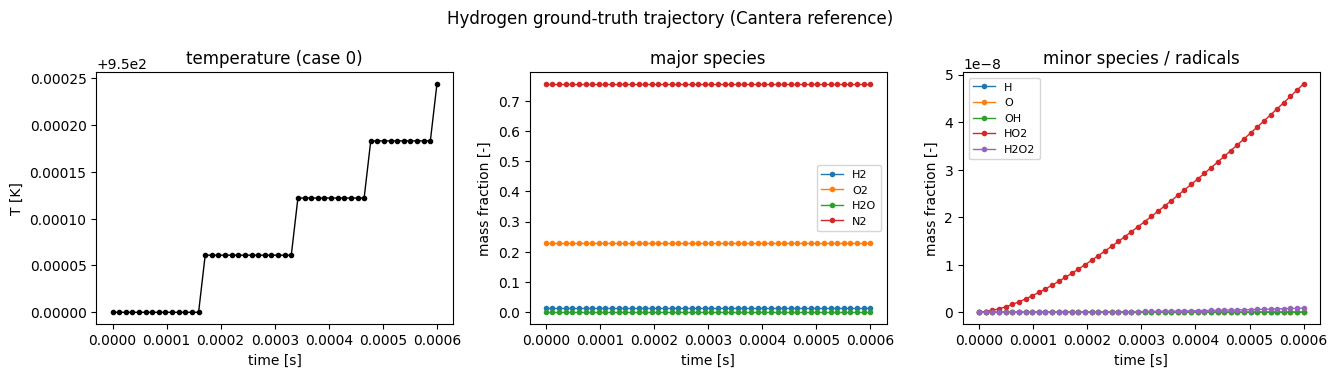

In [8]:
# reference (Cantera) temperature + representative species for one training trajectory
j = 0
T_ref = full[:, j, m_hy]                                 # last column = temperature [K]
major = ["H2", "O2", "H2O", "N2"]
minor = ["H", "O", "OH", "HO2", "H2O2"]
idx = {s: hy_species.index(s) for s in hy_species}

fig, (a0, a1, a2) = plt.subplots(1, 3, figsize=(13.5, 3.8))
a0.plot(t_hy, T_ref, "k-o", ms=3, lw=1); a0.set_title(f"temperature (case {j})")
a0.set_xlabel("time [s]"); a0.set_ylabel("T [K]")
for s in major:
    a1.plot(t_hy, full[:, j, idx[s]], marker="o", ms=3, lw=1, label=s)
a1.set_title("major species"); a1.set_xlabel("time [s]"); a1.set_ylabel("mass fraction [-]"); a1.legend(fontsize=8)
for s in minor:
    a2.plot(t_hy, full[:, j, idx[s]], marker="o", ms=3, lw=1, label=s)
a2.set_title("minor species / radicals"); a2.set_xlabel("time [s]"); a2.set_ylabel("mass fraction [-]"); a2.legend(fontsize=8)
fig.suptitle("Hydrogen ground-truth trajectory (Cantera reference)")
fig.tight_layout(); plt.show()

## 7 · Hydrogen ChemKAN result

Mirrors `scripts/evaluate_hydrogen.py` (full `[Y,T]` integration with the complete ChemKAN).
Rendered Fig.-7-style: temperature, major species, and minor species on separate panels,
plus ignition-delay and element-conservation diagnostics. Runs only if a checkpoint exists.

parameters: 344   (expect 344, base off)
training  : {'learning_rate': 0.002, 'stage1_epochs': 10000, 'stage2_epochs': 10000, 'seed': 0, 'alpha_pinn': 0.0001, 'use_pinn_stage1': False, 'use_pinn_stage2': True}
TEST normalized full-state MSE : 3.161e+00
temperature RMSE               : 1415.53 K
max |T error|                  : 1604.07 K
ignition delay (max dT/dt)     : truth 7.347e-05 s | pred 6.122e-05 s | rel. err 16.67%


### ⚠️ Hydrogen model NOT yet converged — **preliminary** result
Stage-1/Stage-2 = **10000/10000 epochs** (PINN stage-2 = True). Current normalized MSE **3.16** and temperature RMSE **1416 K** show the stiff H₂/O₂ ignition problem is not yet fit — it needs substantially more Stage-2 training / tuning. The panels below show *current* behavior, not final accuracy.

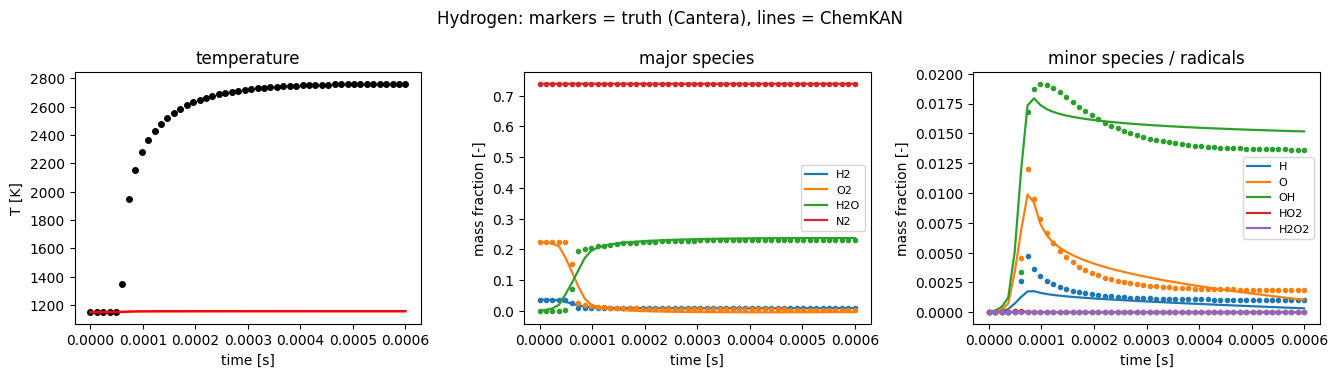

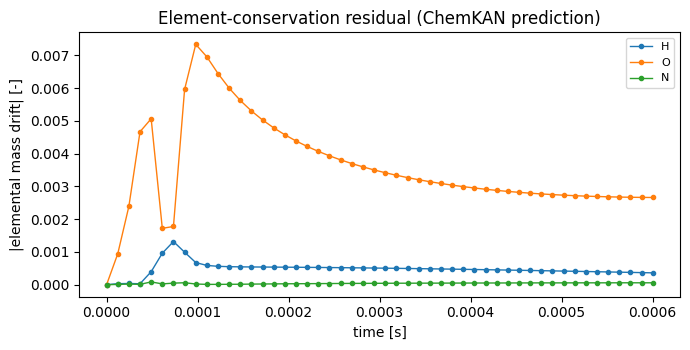

element drift  max: 7.339e-03   mean: 1.362e-03


In [9]:
from chemkan.model import ChemKAN
from chemkan.dynamics import ChemKANDynamics
from _chemistry import ELEMENT_COUNTS, ATOMIC_WEIGHTS, MOLAR_WEIGHTS

def ignition_delay(T_series, t):
    # ignition delay ~ time of maximum dT/dt (coarse at low time resolution)
    dTdt = np.gradient(np.asarray(T_series, float), np.asarray(t, float))
    return float(t[int(np.argmax(dTdt))])

if HYDROGEN_CKPT is None:
    display(Markdown(
        "### ⚠️ NOT AVAILABLE YET — no hydrogen checkpoint found\n"
        "Two-stage training is pending. Generate it (from `chemkan/`):\n\n"
        "```bash\n"
        "python scripts/train_hydrogen.py --stage1-epochs 2000 --stage2-epochs 2000\n"
        "```\n"
        "then re-run §7. (Stage 1: species-only with observed T(t); Stage 2: full [Y,T] "
        "with the thermodynamic superstructure + optional PINN.)"))
else:
    hy_test = load_hydrogen("test")
    ckpt = torch.load(HYDROGEN_CKPT, map_location=DEVICE, weights_only=False)
    arch = ckpt["architecture"]
    model = ChemKAN(species_dim=m_hy, hidden_dim=arch["hidden_dim"],
                    num_basis=arch["num_basis"], n_mu=arch["n_mu"],
                    use_base_act=arch["use_base_act"]).to(DEVICE)
    model.load_state_dict(ckpt["model_state"]); model.eval()
    input_norm = load_input_scaling(ckpt, DEVICE)
    solver = _solver_from_ckpt(ckpt)
    norm = MinMaxNormalizer(hy_test["u_min"], hy_test["u_max"]).to(DEVICE)
    dyn = ChemKANDynamics(model, input_normalizer=input_norm).to(DEVICE)

    u0 = hy_test["full_TBm1"][0].to(DEVICE); tt = hy_test["t"].to(DEVICE)
    with torch.no_grad():
        pred = integrate(dyn, u0, tt, solver)             # (T, B, m+1)
        mse = trajectory_mse(norm.normalize(pred),
                             norm.normalize(hy_test["full_TBm1"].to(DEVICE))).item()
    pred = pred.cpu().numpy(); truth = hy_test["full_TBm1"].numpy(); tv = hy_test["t"].numpy()

    j = 0
    T_pred, T_true = pred[:, j, m_hy], truth[:, j, m_hy]
    T_rmse = float(np.sqrt(((T_pred - T_true) ** 2).mean()))
    T_maxe = float(np.abs(T_pred - T_true).max())
    id_true, id_pred = ignition_delay(T_true, tv), ignition_delay(T_pred, tv)
    id_relerr = abs(id_pred - id_true) / max(id_true, 1e-30)
    print(f"parameters: {sum(p.numel() for p in model.parameters())}   (expect 344, base off)")
    print(f"training  : {ckpt.get('training')}")
    print(f"TEST normalized full-state MSE : {mse:.3e}")
    print(f"temperature RMSE               : {T_rmse:.2f} K")
    print(f"max |T error|                  : {T_maxe:.2f} K")
    print(f"ignition delay (max dT/dt)     : truth {id_true:.3e} s | pred {id_pred:.3e} s "
          f"| rel. err {id_relerr:.2%}")

    tr = ckpt.get("training", {})
    if mse > 1.0 or T_rmse > 50.0:
        display(Markdown(
            f"### ⚠️ Hydrogen model NOT yet converged — **preliminary** result\n"
            f"Stage-1/Stage-2 = **{tr.get('stage1_epochs')}/{tr.get('stage2_epochs')} epochs** "
            f"(PINN stage-2 = {tr.get('use_pinn_stage2')}). Current normalized MSE "
            f"**{mse:.2f}** and temperature RMSE **{T_rmse:.0f} K** show the stiff H₂/O₂ "
            f"ignition problem is not yet fit — it needs substantially more Stage-2 training / "
            f"tuning. The panels below show *current* behavior, not final accuracy."))

    fig, (a0, a1, a2) = plt.subplots(1, 3, figsize=(13.5, 3.8))
    a0.plot(tv, T_true, "ko", ms=4, ls="none"); a0.plot(tv, T_pred, "r-", lw=1.8)
    a0.set_title("temperature"); a0.set_xlabel("time [s]"); a0.set_ylabel("T [K]")
    for k, s in enumerate(["H2", "O2", "H2O", "N2"]):
        c = f"C{k}"; ii = hy_species.index(s)
        a1.plot(tv, truth[:, j, ii], "o", ms=3, ls="none", color=c)
        a1.plot(tv, pred[:, j, ii], "-", lw=1.6, color=c, label=s)
    a1.set_title("major species"); a1.set_xlabel("time [s]"); a1.set_ylabel("mass fraction [-]"); a1.legend(fontsize=8)
    for k, s in enumerate(["H", "O", "OH", "HO2", "H2O2"]):
        c = f"C{k}"; ii = hy_species.index(s)
        a2.plot(tv, truth[:, j, ii], "o", ms=3, ls="none", color=c)
        a2.plot(tv, pred[:, j, ii], "-", lw=1.6, color=c, label=s)
    a2.set_title("minor species / radicals"); a2.set_xlabel("time [s]"); a2.set_ylabel("mass fraction [-]"); a2.legend(fontsize=8)
    fig.suptitle("Hydrogen: markers = truth (Cantera), lines = ChemKAN")
    fig.tight_layout(); plt.show()

    # element-conservation residual vs time (same formula as losses.element_conservation_loss)
    Yp = torch.as_tensor(pred[:, j, :m_hy])               # (T, m) physical species
    coeff = ELEMENT_COUNTS * ATOMIC_WEIGHTS[:, None] / MOLAR_WEIGHTS[None, :]   # (Ne, m)
    z = torch.einsum("tk,ik->ti", Yp, coeff)              # (T, Ne) elemental mass fraction
    drift = (z - z[0:1]).abs().numpy()
    fig, ax = plt.subplots(figsize=(7, 3.6))
    for i, el in enumerate(ELEMENTS):
        ax.plot(tv, drift[:, i], marker="o", ms=3, lw=1, label=el)
    ax.set_xlabel("time [s]"); ax.set_ylabel("|elemental mass drift| [-]")
    ax.set_title("Element-conservation residual (ChemKAN prediction)")
    ax.legend(fontsize=8); fig.tight_layout(); plt.show()
    print(f"element drift  max: {drift.max():.3e}   mean: {drift.mean():.3e}")

## 8 · Cheap correctness checks

Backup evidence that the vectorized building blocks match their mathematical definition and
that shapes/providers behave. Short by design.

In [10]:
from chemkan.kan.rbf import RBFEdgeFunctions
from chemkan.kan._common import gaussian
from chemkan.model import KineticCore as KC, ChemKAN as CK
from chemkan.temperature import ObservedTemperature

torch.manual_seed(0)
# (a) vectorized RBF edge einsum vs an explicit per-edge computation
edges = RBFEdgeFunctions(in_features=7, out_features=4, num_basis=5, use_base_act=False).double()
x = torch.randn(3, 7).double()
vec = edges(x)                                            # (B, out, in)
xn = torch.tanh(x); psi = gaussian(xn, edges.centers, edges.h)
man = torch.zeros_like(vec)
for b in range(3):
    for o in range(4):
        for i in range(7):
            man[b, o, i] = (psi[b, i, :] * edges.w_rbf[o, i, :]).sum()
print(f"(a) RBF vectorized vs explicit  max|diff| = {(vec - man).abs().max().item():.2e}")

# (b) shape checks for the two model heads
kc = KC(species_dim=6, hidden_dim=4, num_basis=3, n_mu=2, use_base_act=False)
ck = CK(species_dim=9, hidden_dim=3, num_basis=5, n_mu=3, use_base_act=False)
print("(b) KineticCore [B,7]->",  tuple(kc(torch.randn(5, 7)).shape),
      "| ChemKAN [B,10]->",       tuple(ck(torch.randn(5, 10)).shape))

# (c) Stage-1 observed-temperature provider: exact at a saved node, bracketed in between
times = torch.tensor([0.0, 1.0, 2.0]); temps = torch.tensor([[[300.]], [[400.]], [[500.]]])
prov = ObservedTemperature(times, temps)
at_node = prov(torch.tensor(1.0)).item()
mid     = prov(torch.tensor(1.5)).item()
print(f"(c) ObservedTemperature: T(1.0)={at_node:.1f} (=400 exact), "
      f"T(1.5)={mid:.1f} (in (400,500)) -> {400 < mid < 500}")

(a) RBF vectorized vs explicit  max|diff| = 5.55e-17
(b) KineticCore [B,7]-> (5, 6) | ChemKAN [B,10]-> (5, 10)
(c) ObservedTemperature: T(1.0)=400.0 (=400 exact), T(1.5)=450.0 (in (400,500)) -> True


## 9 · Forward Sensitivity Analysis — status

The paper obtains parameter gradients with **Forward Sensitivity Analysis (FSA)**: it
augments the ODE with the sensitivity matrix $S = \partial \mathbf{u}/\partial\boldsymbol\theta$
and integrates it alongside the state,

$$\frac{dS}{dt} = \frac{\partial f}{\partial \mathbf{u}}\,S + \frac{\partial f}{\partial \boldsymbol\theta}.$$

**Current situation in this repository:** training differentiates the ODE solve with
**ordinary reverse-mode autograd through `torchdiffeq.odeint`** (`sensitivity="direct_autograd"`;
`SolverConfig` rejects anything else). This is *not* FSA — it is a different mechanism for
obtaining the same gradients, and we **do not** describe it as FSA. FSA is therefore the
**single largest remaining methodological difference** from the paper.

When implemented, FSA should live as a **project-level sensitivity backend wrapped around the
dynamics** (augmenting the RHS with the $S$ equation), while the ODE solver stays the plain
numerical integrator. It is deliberately **not** implemented in this notebook. See
`src/chemkan/ASSUMPTIONS.md` §9.

## 10 · Next steps & open questions

**Planned work**
1. Exact **FSA** reproduction (sensitivity backend around the dynamics).
2. Complete, clean **biodiesel** reproduction (full ~10⁴-epoch training + evaluation).
3. Biodiesel **noise sweep** + **DeepONet** comparison (dataset already carries noise variants).
4. Hydrogen **Stage 1 → Stage 2** with the **PINN** element-conservation term.
5. **ChemNODE** comparison baseline.
6. **Inference timing** vs. the reference stiff solver (Table I style).
7. **Methane** mechanism extension.
8. **Activation-function interpretability** of the learned KAN edges.

**Open questions**
1. **FSA priority** — is exact FSA reproduction required for the project's claims, or is
   autograd-through-`odeint` (same gradients, different method) acceptable as a documented
   deviation?
2. **Chemistry metrics** — which physical diagnostics matter most for judging success:
   ignition-delay error, temperature RMSE, per-species radical accuracy, or element
   conservation?
3. **Extensions vs. baselines** — prioritize new chemistry (methane) and interpretability, or
   the comparison baselines (DeepONet / ChemNODE / timing) first?